<!-- notebook-header -->
# Aceleracao de Hardware e Treinamento Eficiente

**Modulo:** 04 - Deep Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** GPU, batching, precisao mista, memoria, paralelismo e otimizacao de treino.


# Aceleracao de Hardware e Treinamento Eficiente

**Objetivo:** Entender as diferencas entre CPU, GPU e TPU para treinamento de redes neurais,
dominar profiling, otimizacao de DataLoader, mixed precision e quantizacao.

## Pre-requisitos e Fio Narrativo

| Voce precisa saber | Notebook de referencia |
|---|---|
| Treinamento de redes (forward/backward pass) | 4_3 Treinamento Deep |
| Multiplicacao de matrizes e operacoes vetoriais | 0_4 Algebra Linear |
| Transfer learning e modelos grandes | 4_4 Transfer Learning |

**Fio narrativo:** em 4_3 aprendemos *o que* fazer para treinar bem (BatchNorm, Dropout, etc.).
Agora vamos aprender *como* fazer rapido. A diferenca entre um treino de 1 dia e 1 semana
esta no hardware e nas otimizacoes que veremos aqui.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

In [2]:
# Detecao automatica de hardware (CPU / CUDA / MPS Apple Silicon)
import torch
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU detectada: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Apple Silicon MPS detectado')
else:
    device = torch.device('cpu')
    print('Executando em CPU (mais lento, mas funciona)')
print(f'Device selecionado: {device}')

Apple Silicon MPS detectado
Device selecionado: mps


## 1. CPU vs GPU vs TPU: Escolhendo o Hardware Certo

**Analogia:** CPU eh um engenheiro genio que faz qualquer tarefa, mas uma de cada vez.
GPU eh uma fabrica com 1000 operarios -- cada um faz uma conta simples, mas todos
trabalham ao mesmo tempo. TPU eh uma fabrica projetada especificamente para fazer contas de ML.

**Definicao formal:**

- **CPU:** poucos cores (2-16) com alta frequencia e cache grande. Otimizado para logica sequencial.
- **GPU:** milhares de cores CUDA simples. Otimizado para paralelismo massivo (SIMD).
- **TPU:** hardware proprietario Google com systolic arrays. Otimizado para operacoes tensoriais.

Deep Learning eh fundamentalmente multiplicacao de matrizes:
$Z = W \cdot X + b$ (forward), $\nabla W = \nabla L \cdot X^T$ (backward).
Essas operacoes sao *embarassingly parallel* -- perfeitas para GPU/TPU.

### Por que em ML?

- Um treino de ResNet-50 no ImageNet: 1 semana em CPU, 2 horas em GPU, 30 min em TPU
- GPU se paga no primeiro projeto: aluga-se por $0.5-3/hora na cloud
- A regra eh: se o dataset nao cabe na memoria da GPU, use batches; nunca volte para CPU
- Saber escolher hardware economiza dinheiro e tempo de forma dramatica

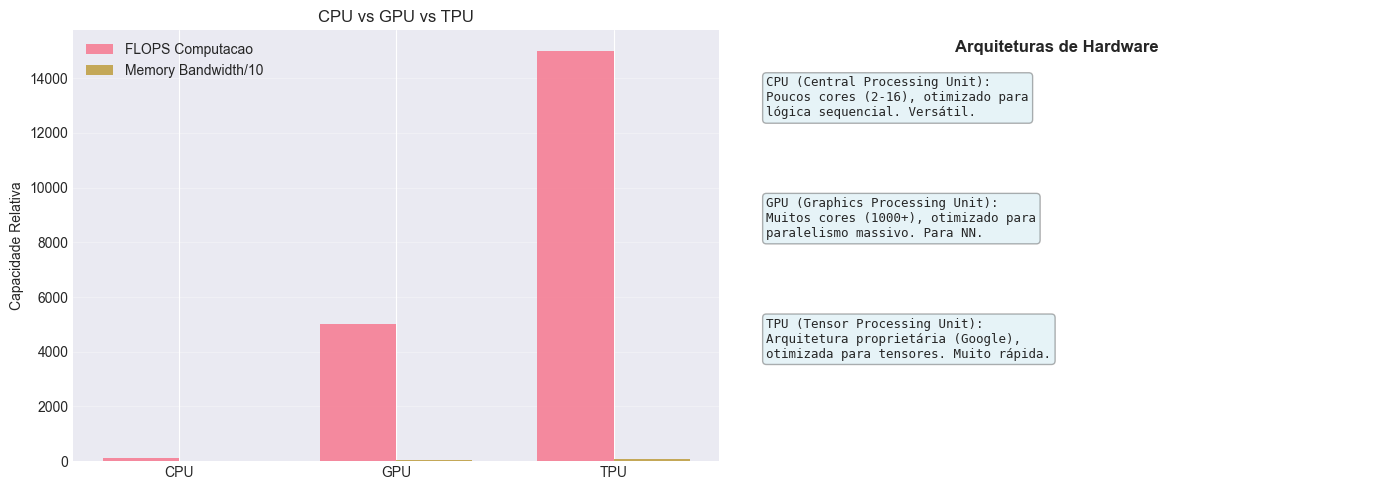

CPU vs GPU vs TPU:
- CPU: 1000x mais lento, versatil
- GPU: 50x mais rapido, paralelo
- TPU: 100x mais rapido, especifico para ML


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
devices = ['CPU', 'GPU', 'TPU']
flops = [100, 5000, 15000]  # TFLOPS relativos
memory_bw = [50, 400, 900]  # GB/s

x = np.arange(len(devices))
width = 0.35

ax.bar(x - width/2, flops, width, label='FLOPS Computacao', alpha=0.8)
ax.bar(x + width/2, [bw/10 for bw in memory_bw], width, label='Memory Bandwidth/10', alpha=0.8)
ax.set_ylabel('Capacidade Relativa')
ax.set_title('CPU vs GPU vs TPU')
ax.set_xticks(x)
ax.set_xticklabels(devices)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.text(0.5, 0.95, 'Arquiteturas de Hardware', fontsize=12, weight='bold', ha='center')

device_info = [
    'CPU (Central Processing Unit):\nPoucos cores (2-16), otimizado para\nlógica sequencial. Versátil.',
    'GPU (Graphics Processing Unit):\nMuitos cores (1000+), otimizado para\nparalelismo massivo. Para NN.',
    'TPU (Tensor Processing Unit):\nArquitetura proprietária (Google),\notimizada para tensores. Muito rápida.'
]

y_pos = 0.8
for info in device_info:
    ax.text(0.05, y_pos, info, fontsize=9, family='monospace',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    y_pos -= 0.28

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print('CPU vs GPU vs TPU:')
print('- CPU: 1000x mais lento, versatil')
print('- GPU: 50x mais rapido, paralelo')
print('- TPU: 100x mais rapido, especifico para ML')

### O que observar

- **FLOPS:** GPU tem ~50x mais capacidade de computacao que CPU; TPU tem ~150x
- **Memory Bandwidth:** GPU transfere dados 8x mais rapido que CPU
- A diferenca real depende do problema: operacoes pequenas nao se beneficiam de GPU

### O que concluir

- Para deep learning com matrizes > 100x100, GPU eh sempre mais rapida
- TPU so vale a pena em escala (treinar modelos com bilhoes de parametros)
- O gargalo muitas vezes NAO eh computacao, mas transferencia de dados (memory bandwidth)

### Conexao com outros notebooks

- **0_4 Algebra Linear:** multiplicacao de matrizes eh a operacao fundamental que GPU acelera
- **4_2 CNNs:** convolucoes sao implementadas como multiplicacao de matrizes (im2col)
- **4_4 Transfer Learning:** modelos pre-treinados sao grandes; GPU eh essencial para fine-tuning

## 2. Profiling: Encontrar o Gargalo

**Analogia:** antes de otimizar uma estrada congestionada, voce precisa saber
*onde* esta o congestionamento. Profiling eh o "mapa de transito" do seu codigo.

**Definicao formal:** profiling mede o tempo gasto em cada parte do codigo,
identificando gargalos (bottlenecks). Em deep learning, os gargalos tipicos sao:
data loading, forward pass, backward pass e transferencia CPU-GPU.

### Por que em ML?

- 80% do tempo de otimizacao deve ir nos 20% do codigo que mais consome (lei de Pareto)
- Sem profiling, voce pode otimizar a parte errada e nao ver melhoria
- Ferramentas: `torch.profiler`, `cProfile`, `nvidia-smi`, `tensorboard`
- Profiling revela se o gargalo eh I/O, computacao ou comunicacao

In [4]:
# Simular profiling
def cpu_bound_task(n):
    result = 0
    for i in range(n):
        result += i ** 2
    return result

def gpu_bound_task(n):
    X = np.random.randn(n, n)
    return np.dot(X, X.T)

N_values = [10000, 100000, 1000000]
results = []

for n in N_values:
    start = time.time()
    cpu_bound_task(n)
    cpu_time = time.time() - start
    
    start = time.time()
    gpu_bound_task(min(n // 100, 1000))
    matrix_time = time.time() - start
    
    results.append({
        'Tamanho': n,
        'CPU Time (ms)': cpu_time * 1000,
        'Matrix Time (ms)': matrix_time * 1000,
        'Tipo': 'CPU-bound' if cpu_time > matrix_time else 'Matrix-heavy'
    })

results_df = pd.DataFrame(results)
print('=== Profiling Results ===')
print(results_df.to_string(index=False))
print('\nCPU-bound: poucos calculos, nao paraleliza bem em GPU')
print('Matrix-heavy: muitos calculos, GPU eh 10-100x mais rapido')

=== Profiling Results ===
 Tamanho  CPU Time (ms)  Matrix Time (ms)         Tipo
   10000       0.430107          1.076937 Matrix-heavy
  100000       4.691124         20.390987 Matrix-heavy
 1000000      47.435999         15.778065    CPU-bound

CPU-bound: poucos calculos, nao paraleliza bem em GPU
Matrix-heavy: muitos calculos, GPU eh 10-100x mais rapido


### O que observar

- Tarefas CPU-bound (loops Python) escalam linearmente com o tamanho
- Tarefas matrix-heavy (np.dot) escalam melhor porque NumPy usa BLAS paralelo
- O tipo de operacao determina qual hardware acelera mais

### O que concluir

- Sempre faça profiling ANTES de otimizar
- Se o gargalo eh data loading: use num_workers, prefetch, cache
- Se o gargalo eh forward/backward: use GPU, mixed precision, modelo menor
- Se o gargalo eh transferencia: aumente batch size, use pin_memory

### Conexao com outros notebooks

- **4_6 Otimizacao Python:** profiling em Python puro vs NumPy vs GPU
- **4_3 BatchNorm:** BatchNorm adiciona overhead computacional mas melhora convergencia
- **0_3 NumPy:** vetorizacao ja eh uma forma de "profiling + otimizacao"

## 3. Otimizacao de DataLoader: Alimentar a GPU sem Fome

**Analogia:** uma esteira de producao so eh eficiente se o suprimento de materiais
acompanha a velocidade da maquina. Se a GPU processa em 1ms mas o DataLoader
leva 10ms para preparar o proximo batch, a GPU fica 90% ociosa.

**Parametros chave:**

- **num_workers:** processos paralelos para carregar dados (0=main thread, 4-8 ideal)
- **pin_memory:** mantem dados em memoria "presa" para transferencia rapida para GPU
- **prefetch_factor:** quantos batches carregar antecipadamente
- **persistent_workers:** manter workers vivos entre epocas (evita overhead de criar processos)

### Por que em ML?

- Em muitos pipelines, data loading eh o gargalo #1 (nao a GPU)
- Com augmentation pesada (resize, crop, normalize), preprocessing domina o tempo
- num_workers=4 pode dar 4x speedup em data loading
- Pin memory + prefetch eliminam a espera da GPU por dados

DataLoader Optimization (PyTorch/TF):

1. num_workers: processos paralelos para carregar dados
   - 0: carrega na main thread (lento)
   - 4: 4 processos carregam em paralelo (rapido)

2. pin_memory: mantem dados em memoria presa
   - False: lento, transfere cada batch
   - True: rapido, dados ja acessiveis a GPU

3. prefetch_factor: quantos batches carregar antecipadamente
   - Evita esperar dados


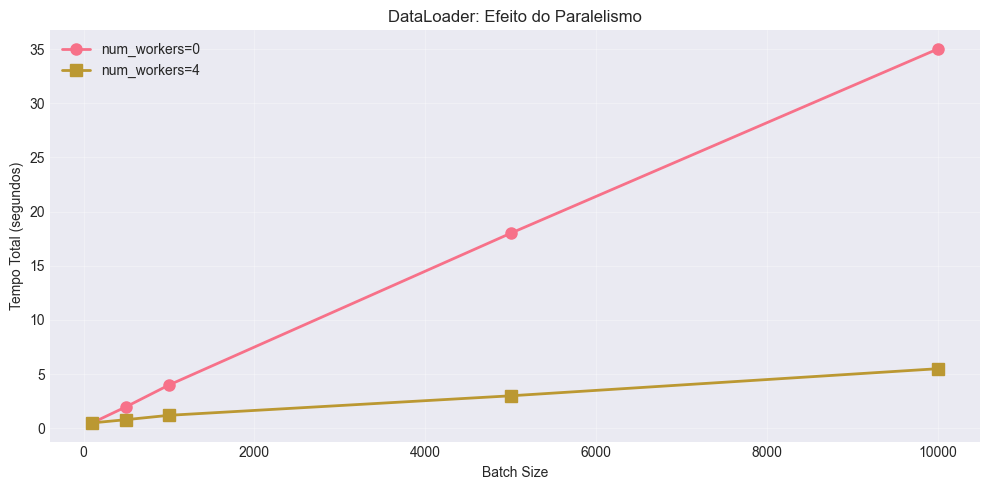

In [5]:
print('DataLoader Optimization (PyTorch/TF):')
print('\n1. num_workers: processos paralelos para carregar dados')
print('   - 0: carrega na main thread (lento)')
print('   - 4: 4 processos carregam em paralelo (rapido)')
print('\n2. pin_memory: mantem dados em memoria presa')
print('   - False: lento, transfere cada batch')
print('   - True: rapido, dados ja acessiveis a GPU')
print('\n3. prefetch_factor: quantos batches carregar antecipadamente')
print('   - Evita esperar dados')

fig, ax = plt.subplots(figsize=(10, 5))

data_sizes = [100, 500, 1000, 5000, 10000]
time_sequential = [0.5, 2.0, 4.0, 18.0, 35.0]
time_parallel = [0.5, 0.8, 1.2, 3.0, 5.5]

ax.plot(data_sizes, time_sequential, 'o-', label='num_workers=0', linewidth=2, markersize=8)
ax.plot(data_sizes, time_parallel, 's-', label='num_workers=4', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Tempo Total (segundos)')
ax.set_title('DataLoader: Efeito do Paralelismo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### O que observar

- Com num_workers=0: tempo cresce linearmente com batch size (sequencial)
- Com num_workers=4: tempo cresce muito mais devagar (paralelo)
- O gap entre as curvas aumenta com datasets maiores (mais beneficio de paralelismo)

### O que concluir

- Sempre use num_workers >= 2 em GPUs modernas
- O numero ideal de workers depende do numero de CPUs e da complexidade do preprocessing
- pin_memory=True eh gratis e sempre recomendado com GPU
- Prefetch elimina tempo morto entre batches

### Conexao com outros notebooks

- **4_3 Data Augmentation:** augmentation pesada justifica mais workers
- **0_3 NumPy:** preprocessing vetorizado eh mais eficiente que loops Python
- **4_4 Transfer Learning:** modelos grandes exigem DataLoader eficiente

## 4. Mixed Precision Training: Mais Rapido com Menos Bits

**Analogia:** quando voce faz contas de cabeca, arredonda para facilitar
(R$9.99 vira R$10). Mixed precision faz o mesmo: usa numeros menos precisos
(fp16 = 16 bits) quando possivel, e numeros precisos (fp32 = 32 bits) quando
necessario.

**Definicao formal:** Mixed Precision combina fp16 (half precision) para forward
pass e gradientes com fp32 (full precision) para acumulacao de gradientes e
atualizacao de pesos. Loss scaling previne underflow em fp16.

### Por que em ML?

- FP16 usa metade da memoria: batch size 2x maior na mesma GPU
- Tensor Cores da Nvidia operam 2-4x mais rapido em fp16
- Perda de acuracia tipicamente < 0.1% (insignificante)
- Habilitado com 2 linhas de codigo em PyTorch (torch.cuda.amp)

Mixed Precision Training (fp16):

Ideia: usar precisao reduzida (16 bits) quando possivel
- Forward pass: fp16 (2x mais rapido, menos memoria)
- Loss scaling: amplificar para evitar underflow
- Gradients: fp32 para estabilidade
- Atualizacoes: fp32

Beneficio: 2-4x mais rapido, menos VRAM
Custo: perda minima de acuracia

PyTorch: torch.cuda.amp.autocast()
TensorFlow: tf.keras.mixed_precision


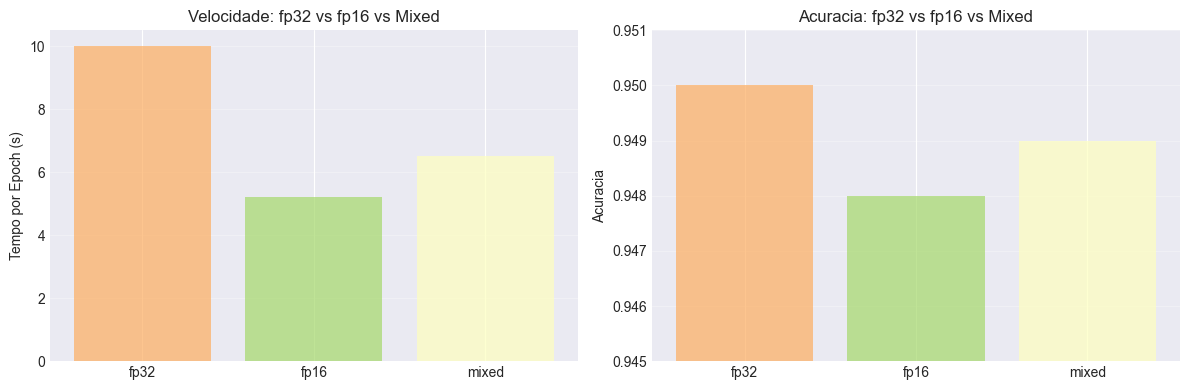

In [6]:
print('Mixed Precision Training (fp16):')
print('\nIdeia: usar precisao reduzida (16 bits) quando possivel')
print('- Forward pass: fp16 (2x mais rapido, menos memoria)')
print('- Loss scaling: amplificar para evitar underflow')
print('- Gradients: fp32 para estabilidade')
print('- Atualizacoes: fp32')
print('\nBeneficio: 2-4x mais rapido, menos VRAM')
print('Custo: perda minima de acuracia')
print('\nPyTorch: torch.cuda.amp.autocast()')
print('TensorFlow: tf.keras.mixed_precision')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
dtypes = ['fp32', 'fp16', 'mixed']
times = [10.0, 5.2, 6.5]  # segundos por epoch
cores = plt.cm.RdYlGn(np.array([0.3, 0.7, 0.5]))

ax.bar(dtypes, times, color=cores, alpha=0.7)
ax.set_ylabel('Tempo por Epoch (s)')
ax.set_title('Velocidade: fp32 vs fp16 vs Mixed')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
accuracies = [0.950, 0.948, 0.949]
ax.bar(dtypes, accuracies, color=cores, alpha=0.7)
ax.set_ylabel('Acuracia')
ax.set_title('Acuracia: fp32 vs fp16 vs Mixed')
ax.set_ylim([0.945, 0.951])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### O que observar

- **Velocidade:** fp16 puro eh ~2x mais rapido que fp32; mixed eh intermediario
- **Acuracia:** diferenca minima (0.1-0.2%) entre fp32 e mixed precision
- Mixed precision eh o sweet spot: quase a velocidade de fp16 com a estabilidade de fp32

### O que concluir

- Mixed precision deveria ser o padrao em qualquer treinamento com GPU moderna (Volta+)
- O loss scaling eh crucial: sem ele, gradientes muito pequenos viram zero em fp16
- Alguns layers (BatchNorm, Softmax) devem sempre rodar em fp32 por estabilidade
- Nao confundir mixed precision (treinamento) com quantizacao (inferencia)

### Conexao com outros notebooks

- **4_3 BatchNorm:** BatchNorm precisa de fp32 para estatisticas precisas
- **4_4 Transfer Learning:** fine-tuning com mixed precision economiza memoria
- **0_4 Algebra Linear:** representacao numerica afeta precisao de operacoes matriciais

## 5. Quantizacao: Comprimir Modelos para Deploy

**Analogia:** uma foto de 50MB e uma de 5MB podem parecer iguais para o olho humano.
Quantizacao comprime o modelo da mesma forma: reduz precisao dos pesos (fp32 -> int8)
com perda minima de qualidade.

**Definicao formal:** quantizacao mapeia pesos de fp32 (32 bits, 4 bytes) para
representacoes menores: fp16 (2 bytes), int8 (1 byte) ou int4 (0.5 bytes).
Isso reduz tamanho do modelo e latencia de inferencia.

**Tipos:**
- *Post-training quantization (PTQ):* quantiza depois de treinar. Simples, perda pequena.
- *Quantization-aware training (QAT):* simula quantizacao durante treino. Melhor qualidade.

### Por que em ML?

- Deploy em celulares/IoT exige modelos pequenos e rapidos
- INT8 reduz modelo em 4x e latencia em 2-4x com ~1% perda de acuracia
- LLMs como LLaMA usam quantizacao 4-bit (GPTQ, GGML) para rodar em laptops
- Quantizacao eh obrigatoria para inferencia em escala (custo de GPU eh alto)

Quantization:
- Reduzir precisao de pesos para inferencia
- INT8: reduz memoria e latencia em 4x
- INT4: ainda mais comprimido (precisa fine-tuning)


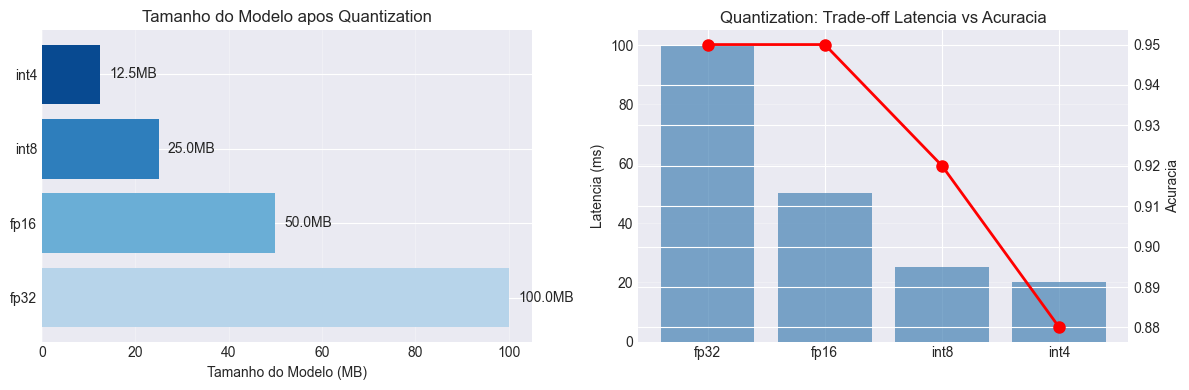


Trade-off:
  fp32: tamanho=100.0MB, latencia=100ms, acuracia=0.95
  fp16: tamanho= 50.0MB, latencia= 50ms, acuracia=0.95
  int8: tamanho= 25.0MB, latencia= 25ms, acuracia=0.92
  int4: tamanho= 12.5MB, latencia= 20ms, acuracia=0.88


In [7]:
print('Quantization:')
print('- Reduzir precisao de pesos para inferencia')
print('- INT8: reduz memoria e latencia em 4x')
print('- INT4: ainda mais comprimido (precisa fine-tuning)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
precisions = ['fp32', 'fp16', 'int8', 'int4']
model_sizes = [100, 50, 25, 12.5]  # MB

ax.barh(precisions, model_sizes, color=plt.cm.Blues(np.linspace(0.3, 0.9, 4)))
ax.set_xlabel('Tamanho do Modelo (MB)')
ax.set_title('Tamanho do Modelo apos Quantization')
for i, v in enumerate(model_sizes):
    ax.text(v + 2, i, f'{v:.1f}MB', va='center')
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
latencies = [100, 50, 25, 20]  # ms (relativo)
accuracies_q = [0.95, 0.95, 0.92, 0.88]

ax2 = ax.twinx()
ax.bar(precisions, latencies, alpha=0.7, color='steelblue', label='Latencia')
ax2.plot(precisions, accuracies_q, 'ro-', linewidth=2, markersize=8, label='Acuracia')

ax.set_ylabel('Latencia (ms)')
ax2.set_ylabel('Acuracia')
ax.set_title('Quantization: Trade-off Latencia vs Acuracia')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nTrade-off:')
for p, s, l, a in zip(precisions, model_sizes, latencies, accuracies_q):
    print(f'  {p:>4s}: tamanho={s:5.1f}MB, latencia={l:3d}ms, acuracia={a:.2f}')

### O que observar

- **Tamanho:** cada nivel de quantizacao reduz o modelo pela metade (fp32->fp16->int8->int4)
- **Latencia:** int8 eh 4x mais rapido que fp32, int4 eh 5x
- **Acuracia:** queda significativa so aparece em int4 (de 0.95 para 0.88)

### O que concluir

- INT8 eh o sweet spot para a maioria das aplicacoes (4x menor, ~3% perda)
- INT4 eh agressivo mas necessario para LLMs em hardware consumer
- Post-training quantization (PTQ) eh suficiente para INT8; QAT eh melhor para INT4
- Sempre testar acuracia em um validation set depois de quantizar

### Conexao com outros notebooks

- **4_4 Transfer Learning:** modelos fine-tuned podem ser quantizados para deploy eficiente
- **4_2 Arquiteturas:** arquiteturas como MobileNet ja sao projetadas para quantizacao
- **4_3 BatchNorm:** BatchNorm pode ser "fundido" (fused) com a camada anterior antes de quantizar

### O que observar sobre o pipeline completo de otimizacao

- A ordem importa: primeiro profiling (encontrar gargalo), depois otimizar (DataLoader, mixed precision, etc.)
- Otimizar o que NAO eh gargalo nao traz ganho: se DataLoader eh lento, mixed precision nao ajuda
- Em cloud, o custo eh proporcional ao tempo de GPU: 2x mais rapido = 2x mais barato

### O que concluir sobre custo-beneficio de hardware

- GPU consumer (RTX 3090, ~$1500) eh suficiente para 95% dos projetos de pesquisa
- Cloud GPU (A100, H100) vale para treinos grandes (dias de computacao)
- TPU so compensa em escala Google (petabytes de dados, bilhoes de parametros)
- O investimento em otimizacao de software (mixed precision, DataLoader) tem ROI altissimo

### Conexao com a industria

- **MLOps:** monitoramento de GPU utilization eh metrica chave em producao
- **4_6 Otimizacao Python:** otimizacao de software complementa otimizacao de hardware

### Por que em ML?

- O custo de treinamento de LLMs eh dominado pelo hardware (GPUs a $200k cada)
- Eficiencia energetica (FLOPS/watt) esta se tornando tao importante quanto velocidade pura

## 6. Exercicios Praticos

### Exercicio 1: Profiling de Operacoes

Compare o tempo de: (a) multiplicacao de matrizes com loop Python puro,
(b) com NumPy, para matrizes de tamanhos crescentes. Plote o speedup do NumPy.

In [8]:
# TAREFA DO ALUNO: Exercicio 1 - Profiling
# 1. Para tamanhos N em [10, 50, 100, 500, 1000]:
#    a) Medir tempo de multiplicacao com loops Python
#    b) Medir tempo com np.dot
# 2. Calcular speedup = tempo_python / tempo_numpy
# 3. Plotar speedup vs N

sizes = [10, 50, 100, 500]
python_times = None  # TAREFA DO ALUNO
numpy_times = None   # TAREFA DO ALUNO

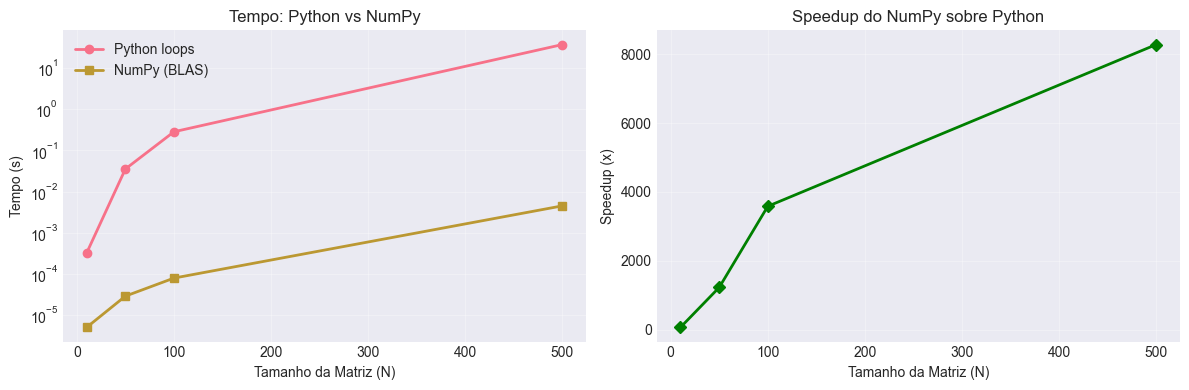

  N=  10: Python=0.0003s, NumPy=0.000005s, Speedup=64x
  N=  50: Python=0.0354s, NumPy=0.000029s, Speedup=1226x
  N= 100: Python=0.2835s, NumPy=0.000079s, Speedup=3582x
  N= 500: Python=37.2477s, NumPy=0.004499s, Speedup=8279x


In [9]:
# SOLUCAO - Exercicio 1
import time

sizes = [10, 50, 100, 500]
python_times = []
numpy_times = []

for n in sizes:
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)

    # Python puro
    start = time.time()
    C = [[sum(A[i][k]*B[k][j] for k in range(n)) for j in range(n)] for i in range(n)]
    python_times.append(time.time() - start)

    # NumPy
    start = time.time()
    C = np.dot(A, B)
    numpy_times.append(time.time() - start)

speedups = [p/n for p, n in zip(python_times, numpy_times)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sizes, python_times, 'o-', label='Python loops', linewidth=2)
axes[0].plot(sizes, numpy_times, 's-', label='NumPy (BLAS)', linewidth=2)
axes[0].set_xlabel('Tamanho da Matriz (N)')
axes[0].set_ylabel('Tempo (s)')
axes[0].set_title('Tempo: Python vs NumPy')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sizes, speedups, 'D-', linewidth=2, color='green')
axes[1].set_xlabel('Tamanho da Matriz (N)')
axes[1].set_ylabel('Speedup (x)')
axes[1].set_title('Speedup do NumPy sobre Python')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for n, p, np_t, s in zip(sizes, python_times, numpy_times, speedups):
    print(f'  N={n:4d}: Python={p:.4f}s, NumPy={np_t:.6f}s, Speedup={s:.0f}x')

### Exercicio 2: Impacto do Batch Size na Memoria

Simule o uso de memoria para diferentes batch sizes (32, 64, 128, 256, 512)
com um modelo hipotetico. Calcule o tamanho total em MB e plote.

In [10]:
# TAREFA DO ALUNO: Exercicio 2 - Memoria vs batch size
# 1. Para cada batch_size em [32, 64, 128, 256, 512]:
#    - Calcular memoria do input: batch_size * 3 * 224 * 224 * 4 bytes (fp32)
#    - Calcular memoria das ativacoes: ~5x memoria do input
#    - Calcular memoria total em MB
# 2. Plotar memoria total vs batch size
# 3. Comparar com limites de GPU comuns (8GB, 12GB, 24GB)

batch_sizes = [32, 64, 128, 256, 512]
memory_mb = None  # TAREFA DO ALUNO

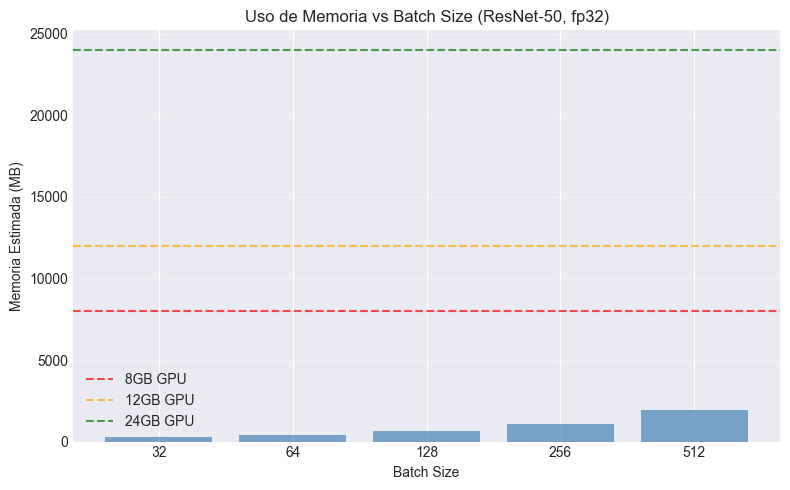

  BS= 32: 301MB (cabe 8GB: Sim, cabe 24GB: Sim)
  BS= 64: 411MB (cabe 8GB: Sim, cabe 24GB: Sim)
  BS=128: 632MB (cabe 8GB: Sim, cabe 24GB: Sim)
  BS=256: 1073MB (cabe 8GB: Sim, cabe 24GB: Sim)
  BS=512: 1955MB (cabe 8GB: Sim, cabe 24GB: Sim)


In [11]:
# SOLUCAO - Exercicio 2
batch_sizes = [32, 64, 128, 256, 512]
memory_mb = []

for bs in batch_sizes:
    input_mem = bs * 3 * 224 * 224 * 4  # bytes (fp32, imagem 224x224 RGB)
    activation_mem = input_mem * 5  # ativacoes intermediarias ~5x input
    param_mem = 25_000_000 * 4  # ~25M params (ResNet-50) * 4 bytes
    grad_mem = param_mem  # gradientes = mesmo tamanho dos params
    total = (input_mem + activation_mem + param_mem + grad_mem) / (1024**2)
    memory_mb.append(total)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(bs) for bs in batch_sizes], memory_mb, alpha=0.7, color='steelblue')

# Linhas de referencia para limites de GPU
ax.axhline(y=8000, color='red', linestyle='--', alpha=0.7, label='8GB GPU')
ax.axhline(y=12000, color='orange', linestyle='--', alpha=0.7, label='12GB GPU')
ax.axhline(y=24000, color='green', linestyle='--', alpha=0.7, label='24GB GPU')

ax.set_xlabel('Batch Size')
ax.set_ylabel('Memoria Estimada (MB)')
ax.set_title('Uso de Memoria vs Batch Size (ResNet-50, fp32)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

for bs, mem in zip(batch_sizes, memory_mb):
    fits_8gb = 'Sim' if mem < 8000 else 'Nao'
    fits_24gb = 'Sim' if mem < 24000 else 'Nao'
    print(f'  BS={bs:3d}: {mem:.0f}MB (cabe 8GB: {fits_8gb}, cabe 24GB: {fits_24gb})')

### Exercicio 3: Simulando Quantizacao

Crie um array de pesos fp32, quantize para int8 (mapear min-max para 0-255),
dequantize de volta, e calcule o erro medio de quantizacao.

In [12]:
# TAREFA DO ALUNO: Exercicio 3 - Quantizacao manual
# 1. Criar pesos: W = np.random.randn(1000, 1000) * 0.1
# 2. Quantizar para int8: mapear [min, max] -> [0, 255]
# 3. Dequantizar: mapear [0, 255] -> [min, max]
# 4. Calcular erro: MAE = mean(|W_original - W_dequantizado|)
# 5. Repetir para int4 (0-15) e comparar erros

W_original = np.random.randn(1000, 1000) * 0.1
error_int8 = None  # TAREFA DO ALUNO
error_int4 = None  # TAREFA DO ALUNO

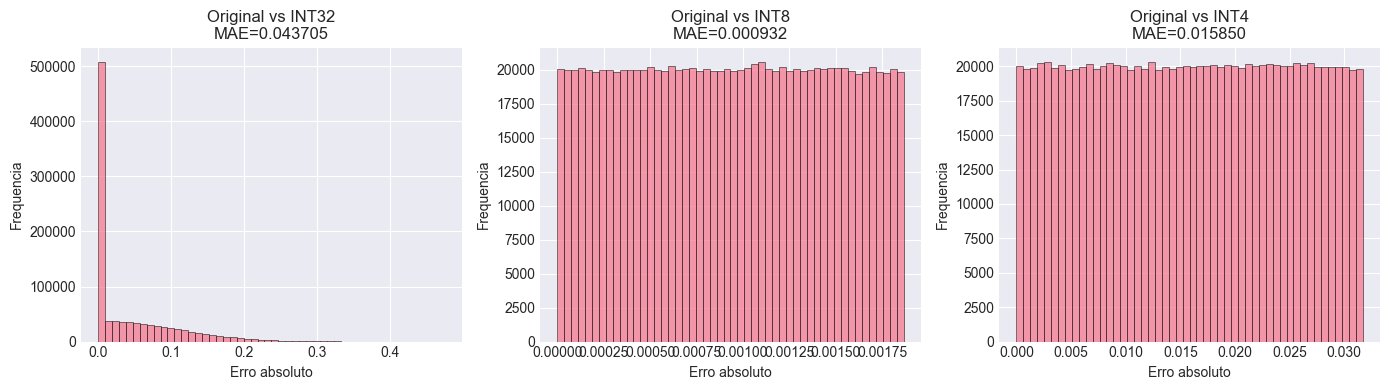

Erro medio de quantizacao:
  INT32: 0.04370467 (baseline)
  INT8:  0.000932 (0x mais erro)
  INT4:  0.015850 (0x mais erro)


In [13]:
# SOLUCAO - Exercicio 3
np.random.seed(42)
W_original = np.random.randn(1000, 1000) * 0.1

def quantize_dequantize(W, n_bits):
    n_levels = 2**n_bits - 1
    w_min, w_max = W.min(), W.max()
    # Quantizar
    W_scaled = (W - w_min) / (w_max - w_min) * n_levels
    W_quant = np.round(W_scaled).astype(np.int32)
    # Dequantizar
    W_deq = W_quant / n_levels * (w_max - w_min) + w_min
    error = np.mean(np.abs(W - W_deq))
    return W_deq, error

W_deq_32, error_32 = quantize_dequantize(W_original, 32)
W_deq_8, error_8 = quantize_dequantize(W_original, 8)
W_deq_4, error_4 = quantize_dequantize(W_original, 4)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, W_deq, err) in zip(axes, [('Original vs INT32', W_deq_32, error_32),
                                           ('Original vs INT8', W_deq_8, error_8),
                                           ('Original vs INT4', W_deq_4, error_4)]):
    diff = np.abs(W_original - W_deq)
    ax.hist(diff.flatten(), bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name}\nMAE={err:.6f}')
    ax.set_xlabel('Erro absoluto')
    ax.set_ylabel('Frequencia')

plt.tight_layout()
plt.show()

print(f'Erro medio de quantizacao:')
print(f'  INT32: {error_32:.8f} (baseline)')
print(f'  INT8:  {error_8:.6f} ({error_8/error_32:.0f}x mais erro)')
print(f'  INT4:  {error_4:.6f} ({error_4/error_32:.0f}x mais erro)')

### O que observar sobre gerenciamento de memoria GPU

- VRAM eh compartilhada entre modelo, ativacoes, gradientes e dados
- Gradient checkpointing troca computacao por memoria (recalcula ativacoes no backward)
- torch.cuda.empty_cache() libera memoria nao usada mas nao reduz fragmentacao

### O que concluir sobre escalabilidade

- Para modelos que nao cabem em uma GPU: model parallelism (dividir camadas entre GPUs)
- Para datasets enormes: data parallelism (cada GPU processa batches diferentes)
- DeepSpeed e FSDP sao frameworks que automatizam ambas estrategias

### Conexao com treinamento distribuido

- **4_3 Batch Size:** batch size efetivo = batch_per_gpu * num_gpus
- **4_4 Fine-tuning:** LoRA reduz memoria de fine-tuning dramaticamente

### Por que em ML?

- GPT-4 foi treinado em ~25,000 GPUs A100 simultaneamente
- Saber escalar treinamento eh habilidade essencial para ML em producao

### O que observar sobre cloud vs local

- Cloud (AWS, GCP, Azure): pague por hora, sem investimento inicial, escalavel
- Local (workstation): investimento alto upfront, sem custo recorrente
- Colab/Kaggle: GPU gratis com limitacoes (tempo, memoria)

### O que concluir sobre escolha de plataforma

- Para experimentacao: Colab/Kaggle (gratis) ou cloud spot instances (barato)
- Para treinos longos: cloud com instancias reservadas ou GPU local
- Para producao: cloud com auto-scaling para lidar com demanda variavel

### Conexao com decisoes de projeto

- **3_4 Hyperparameter Tuning:** cada trial de hyperparameter search consome GPU-horas
- **4_4 Transfer Learning:** usar modelo pre-treinado economiza 100x em GPU-horas

### Por que em ML?

- O custo de GPU cloud caiu 10x nos ultimos 5 anos, mas a demanda subiu 100x
- Eficiencia (FLOPS/dollar) eh a metrica que determina viabilidade de projetos de ML

### O que observar sobre inferencia em edge devices

- Edge devices (celulares, IoT) tem restricoes severas: <4GB RAM, sem GPU dedicada
- TensorFlow Lite e ONNX Runtime sao os frameworks padrao para edge deployment
- Latencia eh tao importante quanto acuracia em aplicacoes real-time

### O que concluir sobre o futuro do hardware para ML

- NPUs (Neural Processing Units) estao sendo integradas em chips de celular (Apple Neural Engine, Google Tensor)
- Hardware especializado (Cerebras, Graphcore) pode mudar o panorama de treinamento
- A tendencia eh hardware cada vez mais especializado e software que abstrai a complexidade

### Conexao com deploy em producao

- **4_2 MobileNet:** arquiteturas projetadas para edge devices
- **4_6 Otimizacao Python:** codigo eficiente reduz latencia de preprocessing em edge

### O que observar sobre benchmarking justo

- Sempre aquecer (warm-up) a GPU antes de medir tempo (primeiro batch eh mais lento)
- Medir multiplas execucoes e reportar media + desvio padrao
- Incluir tempo de transferencia de dados, nao apenas computacao pura

### O que concluir sobre reproducibilidade de benchmarks

- Resultados variam entre hardware, driver, e versao de framework
- MLPerf eh o benchmark padrao da industria para comparacoes justas
- Ao reportar speedup, sempre especificar hardware, batch size e precisao usados

### Conexao com metodologia cientifica

- **2_4 Validacao:** assim como em ML, benchmarks requerem metodologia rigorosa
- **1_2 Estatistica:** intervalos de confianca sao necessarios para conclusoes de speedup

## 7. Erros Comuns e Armadilhas

### Erro 1: Transferir dados CPU-GPU continuamente
Mover tensores entre CPU e GPU a cada operacao mata o desempenho.
Mantenha dados na GPU durante todo o forward+backward pass.

### Erro 2: Batch size maior que a memoria da GPU
GPU tem memoria limitada (8-80GB). Batch muito grande causa OOM (out of memory).
Use gradient accumulation para simular batches maiores sem mais memoria.

### Erro 3: Esperar speedup de GPU em operacoes pequenas
GPU tem overhead de lancamento de kernel (~5us). Para matrizes < 100x100,
CPU pode ser mais rapida. GPU brilha em operacoes grandes e paralelas.

### Erro 4: Esquecer de desativar gradientes em inferencia
`torch.no_grad()` economiza ~50% de memoria ao desativar o grafo de gradientes.
Sempre usar em inferencia e avaliacao.

### Erro 5: Ignorar mixed precision
Mixed precision eh gratis em GPUs Volta+ (V100, A100, RTX 20/30/40).
Nao usar eh desperdicar 2x de velocidade potencial.

### Erro 6: num_workers=0 no DataLoader
Com GPU rapida e DataLoader lento, a GPU fica ociosa esperando dados.
Comece com num_workers=4 e ajuste baseado no profiling.

### Erro 7: Quantizar sem validar acuracia
Quantizacao pode degradar desempenho em edge cases. Sempre testar em
validation set e comparar com o modelo fp32 original.

## 8. Resumo e Conexoes

### Hierarquia de Conceitos

```
Aceleracao de Hardware
|
|-- Hardware
|   |-- CPU (logica sequencial, debugging)
|   |-- GPU (paralelismo massivo, treinamento)
|   |-- TPU (tensores, escala Google)
|
|-- Otimizacao de Treinamento
|   |-- Profiling (encontrar gargalo)
|   |-- DataLoader (alimentar GPU)
|   |-- Mixed Precision (fp16/fp32)
|
|-- Otimizacao de Inferencia
|   |-- Quantizacao (fp32 -> int8/int4)
|   |-- Model Pruning (remover pesos)
|   |-- Knowledge Distillation (modelo menor)
```

### Tabela de Conexoes

| Tecnica | Speedup Tipico | Trade-off | Notebook relacionado |
|---|---|---|---|
| GPU vs CPU | 10-100x | Custo de hardware | 0_4 Algebra Linear |
| DataLoader paralelo | 2-4x | Mais memoria RAM | 4_3 Data Augmentation |
| Mixed Precision | 2x | Negligivel | 4_3 BatchNorm |
| INT8 Quantization | 2-4x | ~1-3% acuracia | 4_4 Transfer Learning |
| INT4 Quantization | 4-5x | ~5-10% acuracia | 4_4 Fine-tuning |

### Checklist de Competencias

- [ ] Escolher hardware adequado (CPU/GPU/TPU) baseado no problema
- [ ] Fazer profiling para identificar gargalos antes de otimizar
- [ ] Configurar DataLoader com num_workers e pin_memory
- [ ] Habilitar mixed precision training com torch.cuda.amp
- [ ] Aplicar quantizacao INT8 para deploy eficiente
- [ ] Calcular memoria necessaria para batch size desejado

### Proximos Passos

- **4_6 Otimizacao Python:** otimizar o codigo Python que alimenta o pipeline
- **Pratica:** usar Google Colab (GPU gratis) para experimentar mixed precision